# [Memory](https://langchain-ai.github.io/langgraph/concepts/memory/)
- LangGraph의 Memory는 AI가 대화 내용을 기억할 수 있게 해주는 기능입니다. 
- 사람이 대화할 때 이전에 말한 내용을 기억하는 것처럼, AI도 과거 대화를 기억해서 더 자연스러운 대화를 할 수 있게 해줍니다.


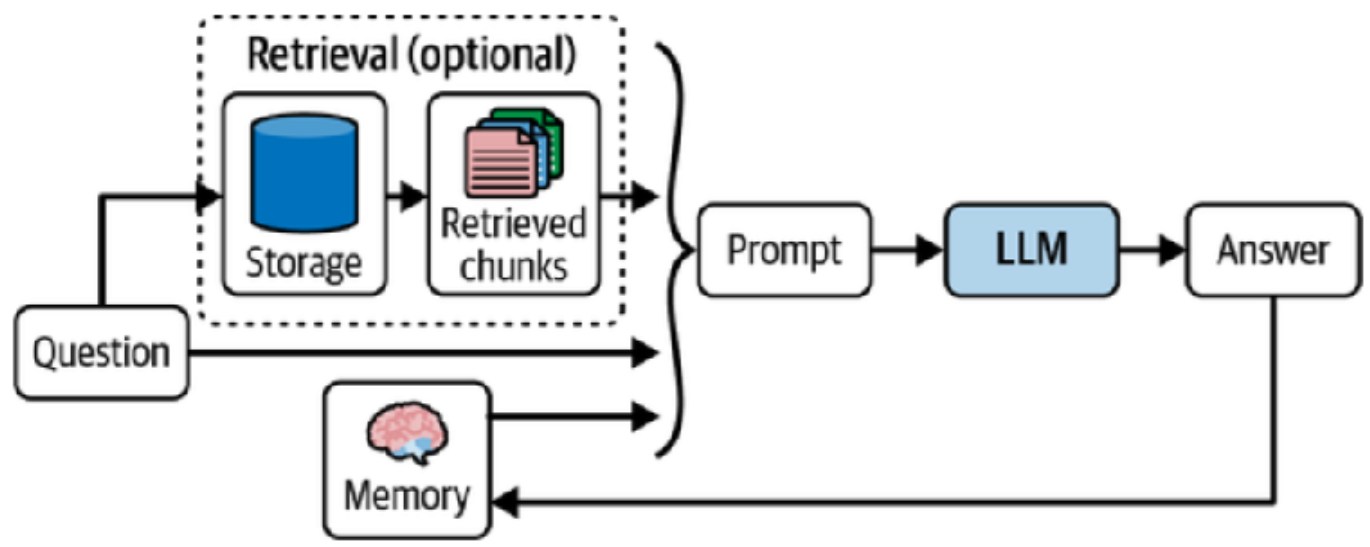

# ConversationSummaryMemory 예시
**오래된 대화를 요약해서 기억하는 똑똑한 챗봇**

모든 대화를 기억하되, 오래된 내용은 요약해서 저장하는 방법입니다!


### 1단계: AI 모델 설정

In [1]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",      # 이미 다운로드된 모델명 
    temperature=0.9,
    top_p=0.9,
    num_predict=512,
    keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
)

### 2단계: 요약 기능이 포함된 노드 정의

In [2]:
from langchain_core.messages import SystemMessage
from langchain_core.prompts import ChatPromptTemplate

def summarize_old_messages(messages, max_messages=4):
    """오래된 메시지들을 AI로 요약하는 함수"""
    # 메시지가 적으면 그대로 반환
    if len(messages) <= max_messages:
        return messages
    
    # 오래된 메시지와 최근 메시지 분리
    old_messages = messages[:-max_messages]
    recent_messages = messages[-max_messages:]
    
    # 요약용 프롬프트 템플릿
    summary_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 대화 내용을 간결하게 요약하는 전문가입니다. 
            다음 대화 내용의 핵심 정보만 추출해서 3-5문장으로 요약해주세요.
            중요한 정보, 결정사항, 맥락을 유지하되 불필요한 세부사항은 생략하세요."""),
        ("user", "다음 대화를 요약해주세요:\n\n{conversation}")
    ])
    
    # 오래된 메시지들을 텍스트로 변환
    conversation_text = ""
    for msg in old_messages:
        if msg.type == "human":
            conversation_text += f"사용자: {msg.content}\n"
        elif msg.type == "ai":
            conversation_text += f"AI: {msg.content}\n"
    
    # AI로 요약 생성
    try:
        summary_chain = summary_prompt | llm
        summary_response = summary_chain.invoke({"conversation": conversation_text})
        summary_content = summary_response.content
    except Exception as e:
        # 요약 실패 시 폴백: 간단한 텍스트 요약
        print(f"AI 요약 실패: {e}")
        summary_content = f"이전 대화 요약 ({len(old_messages)}개 메시지):\n{conversation_text[:500]}..."
    
    # 요약을 시스템 메시지로 만들기
    summary_message = SystemMessage(content=f"[이전 대화 요약]\n{summary_content}")
    
    # 요약본 + 최근 메시지 반환
    return [summary_message] + recent_messages


In [3]:
from langgraph.graph import MessagesState

def chat_node_with_summary(state: MessagesState):
    # 메시지가 너무 많으면 요약
    summarized_messages = summarize_old_messages(state["messages"])
    
    response = llm.invoke(summarized_messages)
    return {"messages": [response]}

### 3단계: 그래프 생성

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END 

graph_summary = StateGraph(MessagesState)
graph_summary.add_node("chat", chat_node_with_summary)
graph_summary.add_edge(START, "chat")
graph_summary.add_edge("chat", END)

### 4단계: 컴파일

In [5]:
from langgraph.checkpoint.memory import MemorySaver

memory_summary = MemorySaver()
app_with_summary = graph_summary.compile(checkpointer=memory_summary)

print("Summary Memory 챗봇이 준비되었습니다! (오래된 대화는 요약해서 기억)")

Summary Memory 챗봇이 준비되었습니다! (오래된 대화는 요약해서 기억)


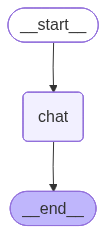

In [6]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app_with_summary.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

### 5단계: 테스트

In [7]:
from langchain_core.messages import HumanMessage
import uuid

# 중요: 같은 thread_id를 사용해야 대화가 연결됩니다!
memory_id = str(uuid.uuid4())
# Summary Memory 테스트
config_summary = {"configurable": {"thread_id": memory_id}}

config_summary

{'configurable': {'thread_id': '25d6489a-0928-44a5-88ea-7cf4fd20331c'}}

In [8]:
# 테스트할 메시지들
test_messages = [
    "내 이름은 김철수야",
    "나는 서울에 살아", 
    "취미는 축구야",
    "오늘 날씨가 좋네",
    "좋아하는 과일은 수박,복숭아야",
    "내 이름과 사는 곳이 뭐였지?"  # 오래된 정보가 요약되어 기억되는지 테스트
]

for i, msg in enumerate(test_messages, 1):
    print(f"{i}번째 대화: '{msg}'")
    result = app_with_summary.invoke(
        {"messages": [HumanMessage(content=msg)]}, 
        config=config_summary
    )
    print(f"AI: {result['messages'][-1].content}")
    print("-" * 40)

print("결과: 오래된 대화는 요약되지만 중요한 정보는 기억합니다!")
print("메모리 효율적이면서도 핵심 정보를 유지해요!")

1번째 대화: '내 이름은 김철수야'
AI: 안녕하세요, 김철수님! 만나서 반갑습니다. 😊 혹시 제가 뭘 도와드릴까요?

----------------------------------------
2번째 대화: '나는 서울에 살아'
AI: 아, 서울에 사시는 김철수님! 서울은 정말 활기찬 도시죠. 혹시 서울에서 특별히 좋아하는 곳이나 즐겨 하시는 활동이 있으신가요? 😊

----------------------------------------
3번째 대화: '취미는 축구야'
AI: 와, 축구 좋아하시는 김철수님! 어떤 팀을 응원하시나요? 좋아하는 선수분도 계신가요? 축구 정말 멋진 운동이죠! 😄

----------------------------------------
4번째 대화: '오늘 날씨가 좋네'
AI: 맞아요! 오늘 날씨 정말 좋네요! 이런 날에는 야외활동을 하기도 좋고, 집에서 편안하게 휴식을 취하기도 좋죠. 김철수님은 오늘 날씨를 어떻게 보내실 계획이신가요? 혹시 특별한 계획이 있으신가요?
----------------------------------------
5번째 대화: '좋아하는 과일은 수박,복숭아야'
AI: 수박이랑 복숭아! 정말 여름에 딱인 과일들인데요! 특히 복숭아는 완전 달콤해서 최고죠. 김철수님은 어떤 복숭아 좋아하시나요? 삭힌 복숭아 좋아하세요, 아니면 그냥 시원한 복숭아를 좋아하세요? 😊
----------------------------------------
6번째 대화: '내 이름과 사는 곳이 뭐였지?'
AI: 김철수님, 다시 한번 말씀드려도 될까요? 김철수님은 서울에 거주하시고, 축구를 취미로 즐기시는 분이시죠! 😊 혹시 기억나시는 대로 다시 한번 말씀해주시면 감사하겠습니다.
----------------------------------------
결과: 오래된 대화는 요약되지만 중요한 정보는 기억합니다!
메모리 효율적이면서도 핵심 정보를 유지해요!


### [Langsmith에서 확인하기](https://smith.langchain.com/)

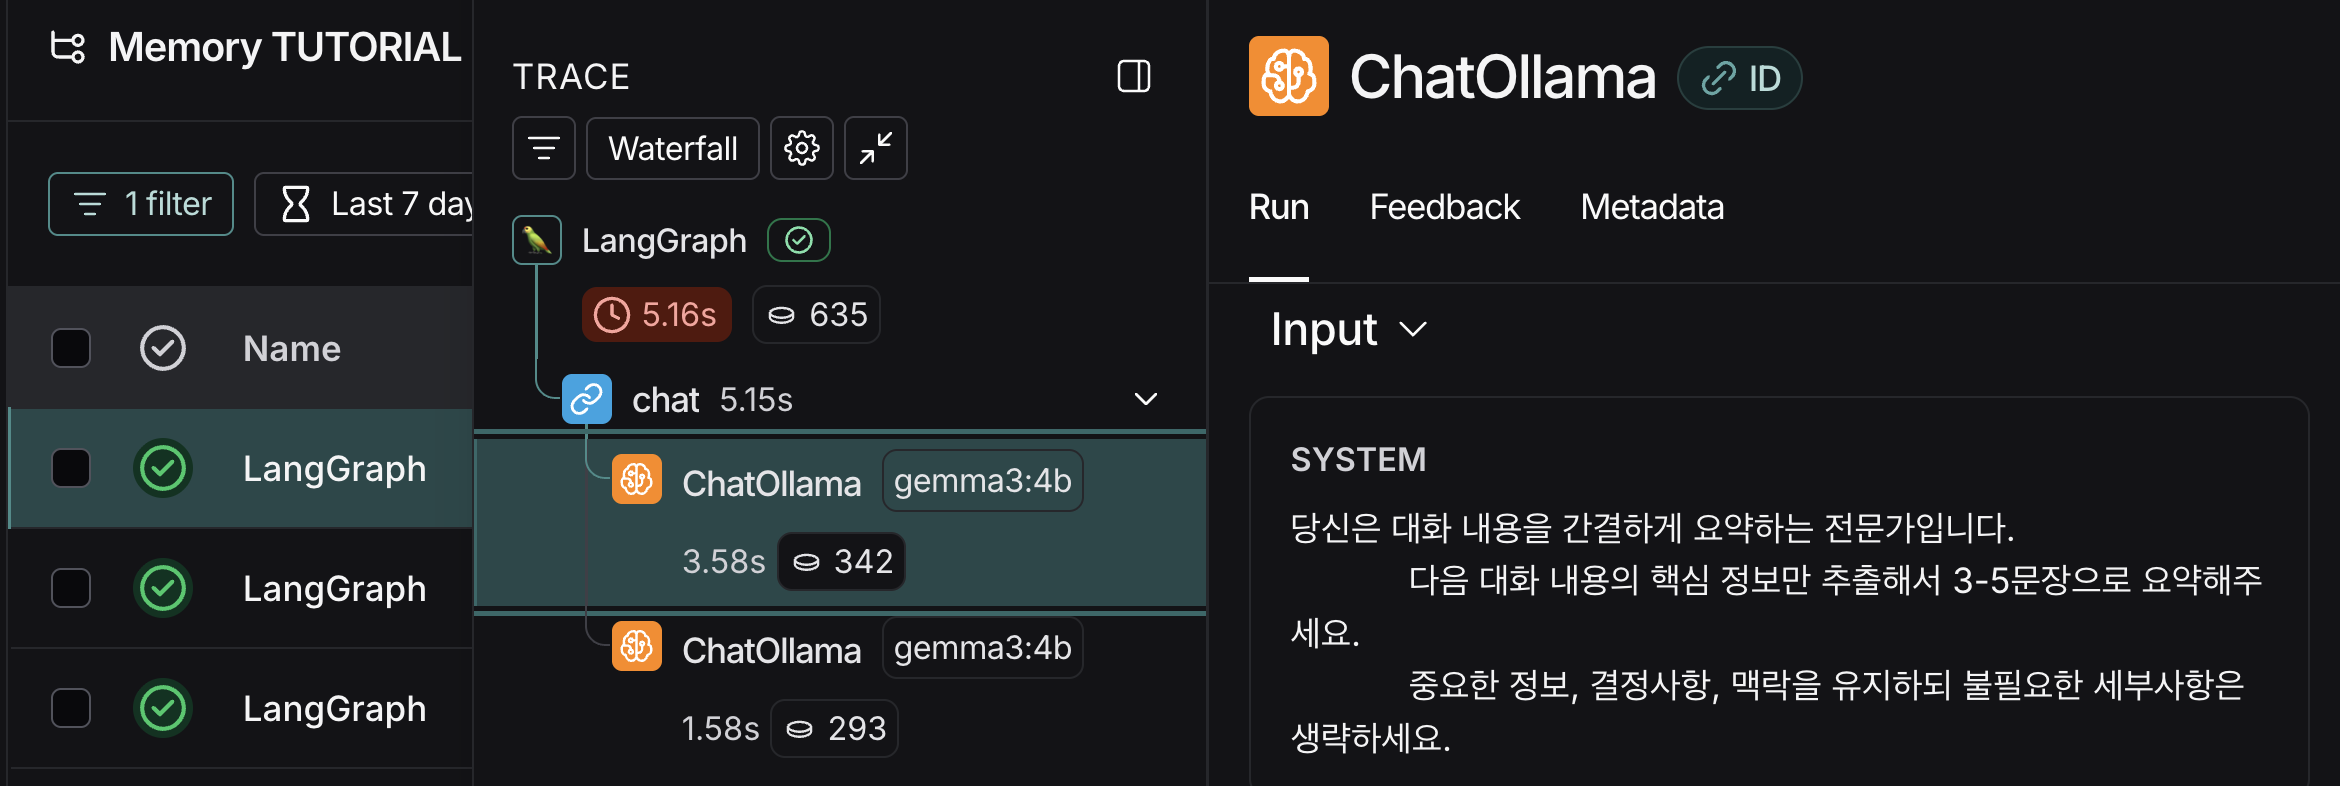